# MOMARL Results Visualization

Visualize Multi-Objective Multi-Agent RL training results from WandB logs.

**Features:** Pareto front, hypervolume comparison, hypervolume learning curve

## 1. Configuration

In [ ]:
from pathlib import Path

# Paths
RESULTS_DIR = Path("../../momarl_results/algo_continous_comparison_v2")
OUTPUT_DIR = Path("./figures/RL_training")

# Hypervolume reference point (origin for maximization)
HYPERVOLUME_REF_POINT = [0.0, 0.0]

# Objective names for axis labels
# objectives are: "global_economic_output", "welfare", "temperature_threshold", "inverse_global_temperature"
OBJECTIVE_NAMES = ["inverse_global_temperature", "global_economic_output"]

# Plot settings
ALGORITHM_COMPARISON = True  # Set to False to plot only one algorithm
COLORS = {"HAPPO": "#81a6fd", "MAPPO": "#f687d1", "UNKNOWN": "#ffb6c1"}
FIGURE_DPI = 150
SAVE_FIGURES = True

# Filter runs with returns below these thresholds (set to None to disable)
MIN_RETURN_OBJ_0 = 0.0
MIN_RETURN_OBJ_1 = 0.0

# WandB settings
USE_WANDB_API = False
WANDB_PROJECT = "momarl_algorithm_comparison"
WANDB_ENTITY = "olaandrasz-tu-delft"

## 2. Imports

In [205]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import warnings

# Hypervolume (DEAP)
try:
    from deap.tools._hypervolume import hv
    HV_AVAILABLE = True
except ImportError:
    HV_AVAILABLE = False
    warnings.warn("DEAP not installed - hypervolume unavailable")

# WandB
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False
    warnings.warn("wandb not installed")

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"HV: {HV_AVAILABLE}, WandB: {WANDB_AVAILABLE}")

if WANDB_AVAILABLE and USE_WANDB_API:
    try:
        wandb.login()
        print("WandB login successful")
    except Exception as e:
        print(f"WandB login failed: {e}")

HV: True, WandB: True


## 3. Data Loading

In [206]:
def load_json(path: Path) -> Optional[Dict]:
    if not path.exists():
        return None
    with open(path, 'r') as f:
        return json.load(f)

def load_yaml(path: Path) -> Optional[Dict]:
    if not path.exists():
        return None
    import yaml
    with open(path, 'r') as f:
        return yaml.safe_load(f)


def parse_run(run_dir: Path) -> Optional[Dict]:
    """Parse a single WandB run directory into a dict."""
    metadata = load_json(run_dir / "files" / "wandb-metadata.json")
    summary = load_json(run_dir / "files" / "wandb-summary.json")
    config = load_yaml(run_dir / "files" / "config.yaml")
    
    if metadata is None or summary is None:
        return None
    
    run_name = run_dir.name
    weights = summary.get("weights", [0.5, 0.5])
    rewards = config.get("rewards", {}).get("value", []) if config else []
    
    return {
        "run_id": run_name,
        "algorithm": config.get("algorithm", {}).get("value", "UNKNOWN").upper() if config else "UNKNOWN",
        "weight_0": weights[0] if weights else 0.0,
        "weight_1": weights[1] if len(weights) > 1 else 0.0,
        "weight_idx": summary.get("weight_idx", -1),
        "reward_0": rewards[0] if len(rewards) > 0 else "",
        "reward_1": rewards[1] if len(rewards) > 1 else "",
        "return_obj_0": summary.get("return_obj_0") or summary.get("final/return_obj_0") or 0.0,
        "return_obj_1": summary.get("return_obj_1") or summary.get("final/return_obj_1") or 0.0,
        "total_steps": summary.get("total_num_steps", 0),
    }


def load_all_runs(results_dir: Path) -> pd.DataFrame:
    """Load all WandB runs from a directory into a DataFrame."""
    run_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir() and (d.name.startswith("run-") or d.name.startswith("offline-run-"))])
    print(len(run_dirs), "runs found in", results_dir)
    rows = [parse_run(d) for d in run_dirs]
    rows = [r for r in rows if r is not None]
    return pd.DataFrame(rows) if rows else pd.DataFrame()

## 4. Load Runs

In [207]:
df = load_all_runs(RESULTS_DIR)

print(f"Loaded {len(df)} runs from {RESULTS_DIR}")
print(df["algorithm"].value_counts())
print(df["reward_0"].value_counts())
print(df["reward_1"].value_counts())

# Filter based on OBJECTIVE_0 and OBJECTIVE_1 names
if OBJECTIVE_NAMES[0] and OBJECTIVE_NAMES[1]:
    df = df[
        (df["reward_0"] == OBJECTIVE_NAMES[0]) &
        (df["reward_1"] == OBJECTIVE_NAMES[1])
    ]
    
print(f"\nAfter filtering by reward names: {len(df)} runs")
print(df["reward_0"].value_counts())
print(df["reward_1"].value_counts())
df.head(10)

184 runs found in ../../momarl_results/algo_continous_comparison_v2
Loaded 101 runs from ../../momarl_results/algo_continous_comparison_v2
algorithm
HAPPO    53
MAPPO    48
Name: count, dtype: int64
reward_0
inverse_global_temperature    101
Name: count, dtype: int64
reward_1
global_economic_output    101
Name: count, dtype: int64

After filtering by reward names: 101 runs
reward_0
inverse_global_temperature    101
Name: count, dtype: int64
reward_1
global_economic_output    101
Name: count, dtype: int64


,run_id,algorithm,weight_0,weight_1,weight_idx,reward_0,reward_1,return_obj_0,return_obj_1,total_steps
0,offline-run-20260414_000317-48qwcggu,HAPPO,0.110350,0.889650,1,inverse_global_temperature,global_economic_output,98.535371,370.832471,1980000
1,offline-run-20260414_000503-gzicypgl,HAPPO,0.210893,0.789107,1,inverse_global_temperature,global_economic_output,105.330910,366.138853,1980000
2,offline-run-20260414_001535-bu8l7mmc,MAPPO,0.009973,0.990027,1,inverse_global_temperature,global_economic_output,70.548824,342.774503,1980000
3,offline-run-20260414_001601-jn2py90j,HAPPO,0.311800,0.688200,1,inverse_global_temperature,global_economic_output,125.197716,320.684450,1980000
4,offline-run-20260414_003602-mirmrkhv,HAPPO,0.019963,0.980037,2,inverse_global_temperature,global_economic_output,78.171596,373.489624,1980000
5,offline-run-20260414_004947-gmljpgg9,HAPPO,0.220884,0.779116,2,inverse_global_temperature,global_economic_output,116.696302,385.419883,1980000
6,offline-run-20260414_005241-yviz15au,HAPPO,0.120377,0.879623,2,inverse_global_temperature,global_economic_output,100.215959,381.461675,1980000
7,offline-run-20260414_005457-gz7gnpvw,MAPPO,0.019963,0.980037,2,inverse_global_temperature,global_economic_output,76.910567,333.731818,1980000
8,offline-run-20260414_005804-oon9vmzd,HAPPO,0.321950,0.678050,2,inverse_global_temperature,global_economic_output,127.176389,343.146428,1980000
9,offline-run-20260414_011805-0yt7i40j,HAPPO,0.029984,0.970016,3,inverse_global_temperature,global_economic_output,84.264917,360.869410,1980000


## 5. Pareto Front

In [208]:
MARKERS = {"HAPPO": "o", "MAPPO": "s", "UNKNOWN": "o"}

# Plotly markers (different naming)
PLOTLY_MARKERS = {"HAPPO": "circle", "MAPPO": "square", "UNKNOWN": "circle"}

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not installed - interactive plots unavailable")


def is_pareto_efficient(points: np.ndarray) -> np.ndarray:
    """Return boolean mask of Pareto-efficient points (maximization)."""
    n = len(points)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and np.all(points[j] >= points[i]) and np.any(points[j] > points[i]):
                is_efficient[i] = False
                break
    return is_efficient


def plot_pareto_front_interactive(df: pd.DataFrame) -> go.Figure:
    """Plot interactive Pareto front with hover info (weight, run_id).
    Includes checkbox to show/hide dominated (non-Pareto) points."""
    fig = go.Figure()
    
    algos = list(df["algorithm"].unique())
    if not ALGORITHM_COMPARISON and len(algos) > 1:
        # When only a single algorithm should be shown, select the most frequent one
        algos = [df["algorithm"].value_counts().idxmax()]
    
    dominated_trace_indices = []  # Track indices of dominated point traces
    trace_idx = 0
    
    for algo in algos:
        algo_df = df[df["algorithm"] == algo].reset_index(drop=True)
        points = algo_df[["return_obj_0", "return_obj_1"]].values
        color = COLORS.get(algo, "#333")
        marker = PLOTLY_MARKERS.get(algo, "circle")
        
        pareto_mask = is_pareto_efficient(points) if len(points) > 0 else np.zeros(len(points), dtype=bool)
        non_pareto_mask = ~pareto_mask
        
        # Create hover text with weight and run_id
        hover_text = [
            f"Run: {row['run_id']}<br>Weight: ({row['weight_0']:.2f}, {row['weight_1']:.2f})<br>"
            f"{OBJECTIVE_NAMES[0]}: {row['return_obj_0']:.2f}<br>{OBJECTIVE_NAMES[1]}: {row['return_obj_1']:.2f}"
            for _, row in algo_df.iterrows()
        ]
        
        # Add dominated (non-Pareto) points first (faded, hidden by default)
        if non_pareto_mask.any():
            non_pareto_df = algo_df[non_pareto_mask]
            non_pareto_hover = [hover_text[i] for i in range(len(algo_df)) if non_pareto_mask[i]]
            fig.add_trace(go.Scatter(
                x=non_pareto_df["return_obj_0"],
                y=non_pareto_df["return_obj_1"],
                mode="markers",
                marker=dict(size=10, color=color, symbol=marker, opacity=0.4,
                           line=dict(width=1, color="gray")),
                name=f"{algo} (dominated)",
                hovertemplate="%{customdata}<extra></extra>",
                customdata=non_pareto_hover,
                visible=False  # Hidden by default
            ))
            dominated_trace_indices.append(trace_idx)
            trace_idx += 1
        
        # Add Pareto points (highlighted)
        if pareto_mask.any():
            pareto_df = algo_df[pareto_mask]
            pareto_hover = [hover_text[i] for i in range(len(algo_df)) if pareto_mask[i]]
            fig.add_trace(go.Scatter(
                x=pareto_df["return_obj_0"],
                y=pareto_df["return_obj_1"],
                mode="markers",
                marker=dict(size=14, color=color, symbol=marker, 
                           line=dict(width=2, color="gray")),
                name=f"{algo} (Pareto)",
                hovertemplate="%{customdata}<extra></extra>",
                customdata=pareto_hover
            ))
            trace_idx += 1
    
    # Create visibility arrays for toggle buttons
    n_traces = len(fig.data)
    # Pareto only: dominated traces hidden
    pareto_only_visible = [True] * n_traces
    for i in dominated_trace_indices:
        pareto_only_visible[i] = False
    
    # All points: everything visible
    all_visible = [True] * n_traces
    
    title_text = "Pareto Front"
    if ALGORITHM_COMPARISON:
        title_text += ": HAPPO vs MAPPO"
    
    fig.update_layout(
        title=dict(text=title_text, font=dict(size=16, weight="bold")),
        xaxis_title=OBJECTIVE_NAMES[0].replace('_', ' ').title(),
        yaxis_title=OBJECTIVE_NAMES[1].replace('_', ' ').title(),
        legend=dict(x=0.98, y=0.98, xanchor="right", yanchor="bottom"),
        hovermode="closest",
        width=900,
        height=650,
        # Add toggle buttons
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                buttons=[
                    dict(
                        args=[{"visible": pareto_only_visible}],
                        label="Pareto Only",
                        method="update"
                    ),
                    dict(
                        args=[{"visible": all_visible}],
                        label="Show All Points",
                        method="update"
                    ),
                ],
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.0,
                xanchor="left",
                y=1.12,
                yanchor="top"
            ),
        ],
    )
    
    return fig


def plot_pareto_front(df: pd.DataFrame, show_weights: bool = True) -> plt.Figure:
    """Plot Pareto front comparison between algorithms (static matplotlib)."""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    algos = list(df["algorithm"].unique())
    if not ALGORITHM_COMPARISON and len(algos) > 1:
        # When only a single algorithm should be shown, select the most frequent one
        algos = [df["algorithm"].value_counts().idxmax()]
    
    for algo in algos:
        algo_df = df[df["algorithm"] == algo]
        points = algo_df[["return_obj_0", "return_obj_1"]].values
        color, marker = COLORS.get(algo, "#333"), MARKERS.get(algo, "x")
        
        pareto_mask = is_pareto_efficient(points) if len(points) > 0 else np.zeros(len(points), dtype=bool)
        
        # Pareto (highlighted)
        if pareto_mask.any():
            if ALGORITHM_COMPARISON:
                ax.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
                      c=color, s=150, marker=marker, alpha=0.9,
                      edgecolors='black', linewidths=1.5, label=f"{algo}")
            else:
                ax.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
                      c=color, s=150, marker=marker, alpha=0.9,
                      edgecolors='gray', linewidths=1.5, label=f"{OBJECTIVE_NAMES}")
        
        # Weight annotations
        if show_weights:
            for _, row in algo_df.iterrows():
                ax.annotate(f"({row['weight_0']:.2f}, {row['weight_1']:.2f})",
                           (row["return_obj_0"], row["return_obj_1"]),
                           textcoords="offset points", xytext=(5, 5 if algo == "HAPPO" else -12),
                           fontsize=7, color=color, alpha=0.8)
    
    ax.set_xlabel(OBJECTIVE_NAMES[0].replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel(OBJECTIVE_NAMES[1].replace('_', ' ').title(), fontsize=12)
    title = "Pareto Front"
    if ALGORITHM_COMPARISON:
        title += ": HAPPO vs MAPPO"
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

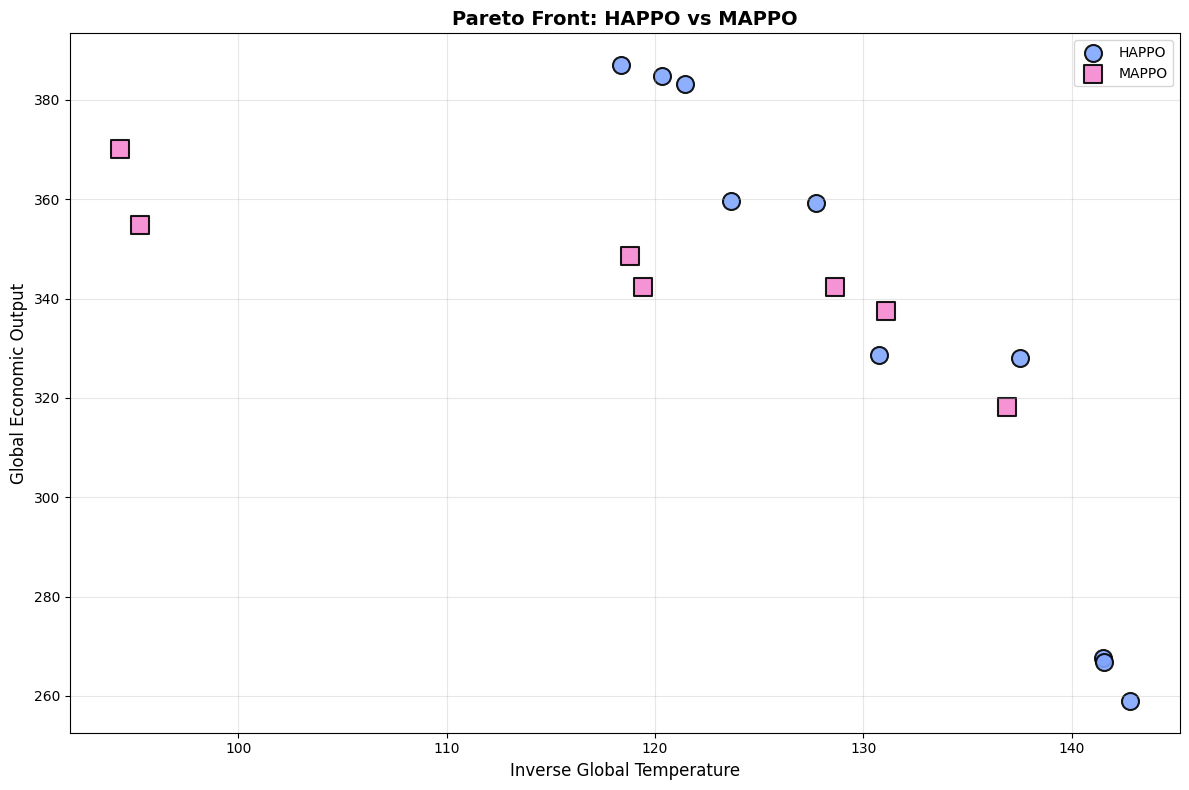

In [209]:
# Interactive plot with hover (Plotly)
if PLOTLY_AVAILABLE:
    fig_pareto_interactive = plot_pareto_front_interactive(df)
    fig_pareto_interactive.show()
else:
    print("Plotly not available, showing static plot")

# Static plot (matplotlib) - for saving
fig_pareto = plot_pareto_front(df, show_weights=False)
if SAVE_FIGURES:
    fig_pareto.savefig(OUTPUT_DIR / "pareto_front.png", dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

## 6. Hypervolume Over Time

In [210]:
def _parse_wandb_file(wandb_file: Path) -> List[Dict]:
    """Parse a .wandb binary file and return history records as list of dicts."""
    from wandb.sdk.internal import datastore
    from wandb.proto import wandb_internal_pb2
    
    ds = datastore.DataStore()
    ds.open_for_scan(str(wandb_file))
    
    records = []
    errors = 0
    while True:
        try:
            data = ds.scan_record()
        except Exception:
            errors += 1
            if errors > 50:
                break
            continue
        if data is None:
            break
        try:
            pb = wandb_internal_pb2.Record()
            pb.ParseFromString(data[1])
        except Exception:
            errors += 1
            continue
        if pb.WhichOneof("record_type") == "history":
            items = {}
            for item in pb.history.item:
                key = item.nested_key[0] if item.nested_key else item.key
                items[key] = item.value_json
            records.append(items)
    return records


def _parse_objective_vector_value(val_str: str, run_dir: Path) -> Optional[np.ndarray]:
    """Parse an objective_vector value from a history record.
    It can be a path to a table JSON file under files/, or inline JSON."""
    if val_str.startswith('"') and val_str.endswith('"'):
        val_str = val_str.strip('"')
    
    # Check if it's a media/table path
    if val_str.startswith("media/"):
        table_path = run_dir / "files" / val_str
        if table_path.exists():
            with open(table_path, "r") as f:
                table = json.load(f)
            return np.array(table["data"])
        return None
    
    # Try parsing as JSON
    try:
        parsed = json.loads(val_str)
        if isinstance(parsed, dict) and "data" in parsed:
            return np.array(parsed["data"])
        elif isinstance(parsed, list):
            return np.array(parsed)
    except Exception:
        pass
    return None


def _fetch_history_from_local(run_dir: Path, run_id: str, algorithm: str) -> Optional[pd.DataFrame]:
    """Parse training history from a local offline wandb run directory."""
    wandb_files = list(run_dir.glob("run-*.wandb"))
    if not wandb_files:
        return None
    
    records = _parse_wandb_file(wandb_files[0])
    if not records:
        return None
    
    # Separate eval records (have eval/ keys) from training records
    eval_rows = []
    for rec in records:
        step = rec.get("_step")
        if step is None:
            continue
        step = int(float(step))
        
        # Check for eval keys
        obj_0 = rec.get("eval/0_mean")
        obj_1 = rec.get("eval/1_mean")
        total_steps = rec.get("eval/total_num_steps") or rec.get("total_num_steps")
        obj_vec_ref = rec.get("eval/objective_vector")
        
        if obj_0 is not None or obj_1 is not None:
            obj_vec = None
            if obj_vec_ref is not None:
                obj_vec = _parse_objective_vector_value(obj_vec_ref, run_dir)
            
            eval_rows.append({
                "total_num_steps": float(total_steps) if total_steps else np.nan,
                "0": float(obj_0) if obj_0 else np.nan,
                "1": float(obj_1) if obj_1 else np.nan,
                "objective_vectors": obj_vec,
                "run_id": run_id,
                "algorithm": algorithm,
            })
    
    if not eval_rows:
        # Fallback: look for records with '0' and '1' keys (older format)
        for rec in records:
            obj_0 = rec.get("0")
            obj_1 = rec.get("1")
            total_steps = rec.get("total_num_steps")
            if obj_0 is not None and obj_1 is not None:
                eval_rows.append({
                    "total_num_steps": float(total_steps) if total_steps else np.nan,
                    "0": float(obj_0),
                    "1": float(obj_1),
                    "objective_vectors": None,
                    "run_id": run_id,
                    "algorithm": algorithm,
                })
    
    if not eval_rows:
        return None
    
    df = pd.DataFrame(eval_rows)
    df["total_num_steps"] = df["total_num_steps"].ffill().bfill()
    return df


def fetch_training_history_from_wandb(runs_df, entity: str, project: str) -> Dict[str, pd.DataFrame]:
    """Fetch eval history for all runs from WandB API or local .wandb files.
    Returns histories dict with algorithm info embedded in each DataFrame.
    Columns: run_id, algorithm, total_num_steps, 0, 1, objective_vectors (list of arrays)."""
    if USE_WANDB_API:
        api = wandb.Api()
    
    histories = {}
    i = 0 
    for run_id, algorithm in zip(runs_df["run_id"], runs_df["algorithm"]):
        
        run_new_id = run_id.split("-")[-1] if "-" in run_id else run_id
        if i % 50 == 0:
            print(f"Fetching history for run {i}/{len(runs_df)}")
        i += 1
        try:
            if USE_WANDB_API:
                online_data = api.run(f"{entity}/{project}/{run_new_id}")
            else:
                # Parse from local .wandb file
                run_dir = RESULTS_DIR / run_id
                hist_df = _fetch_history_from_local(run_dir, run_id, algorithm)
                if hist_df is not None and len(hist_df) > 0:
                    histories[run_id] = hist_df
                continue
        except Exception as e:
            print(f"Failed to fetch run with path {entity}/{project}/{run_new_id}: \n{e}")
            continue
    
        # Fetch each key separately to avoid wandb dropping rows where not all keys are present
        hist_0_means = online_data.history(keys=["eval/0_mean"], pandas=True)
        hist_1_means = online_data.history(keys=["eval/1_mean"], pandas=True)
        hist_total_steps = online_data.history(keys=["total_num_steps"], pandas=True)
        hist_objective_vector = online_data.history(keys=["eval/objective_vector"], pandas=True)
        
        if hist_0_means.empty and hist_1_means.empty:
            print(f"No eval data for {run_new_id}, skipping")
            continue
        
        # Merge on _step index (wandb adds _step column to each history call)
        history_df = pd.DataFrame({"_step": hist_0_means.get("_step", pd.Series(dtype=int))})
        history_df["0"] = hist_0_means.get("eval/0_mean", pd.Series(dtype=float)).values
        
        if not hist_1_means.empty and "_step" in hist_1_means.columns:
            h1 = hist_1_means[["_step", "eval/1_mean"]].rename(columns={"eval/1_mean": "1"})
            history_df = history_df.merge(h1, on="_step", how="outer")
        else:
            history_df["1"] = np.nan
        
        if not hist_total_steps.empty and "_step" in hist_total_steps.columns:
            ht = hist_total_steps[["_step", "total_num_steps"]]
            history_df = history_df.merge(ht, on="_step", how="outer")
        else:
            history_df["total_num_steps"] = np.nan
        
        history_df = history_df.sort_values("_step").reset_index(drop=True)
        history_df["total_num_steps"] = history_df["total_num_steps"].ffill().bfill()
        history_df["run_id"] = run_id
        history_df["algorithm"] = algorithm
        
        # Parse objective_vector column: wandb Tables come back as dicts or strings
        obj_vectors = []
        vec_col = hist_objective_vector.get("eval/objective_vector")
        vec_steps = hist_objective_vector.get("_step")
        
        # Build a step -> vector mapping
        vec_by_step = {}
        if vec_col is not None and vec_steps is not None:
            for step_val, val in zip(vec_steps, vec_col):
                if val is None or (isinstance(val, float) and np.isnan(val)):
                    vec_by_step[step_val] = None
                elif isinstance(val, dict) and "data" in val:
                    vec_by_step[step_val] = np.array(val["data"])
                elif isinstance(val, list):
                    vec_by_step[step_val] = np.array(val)
                elif isinstance(val, str):
                    import json as _json
                    try:
                        parsed = _json.loads(val)
                        if isinstance(parsed, dict) and "data" in parsed:
                            vec_by_step[step_val] = np.array(parsed["data"])
                        else:
                            vec_by_step[step_val] = np.array(parsed)
                    except Exception:
                        vec_by_step[step_val] = None
                else:
                    vec_by_step[step_val] = None
        
        # Align vectors with history_df rows by _step
        history_df["objective_vectors"] = [vec_by_step.get(s) for s in history_df["_step"]]
        history_df = history_df.drop(columns=["_step"])
        
        histories[run_id] = history_df
    return histories

In [211]:
# print("Fetching from WandB API...")
# api = wandb.Api()
# print(api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}"))
# for run in api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}"):
#     print(run.path)
# print(WANDB_ENTITY, WANDB_PROJECT)

In [212]:
if WANDB_AVAILABLE and USE_WANDB_API and HV_AVAILABLE:
    print("Fetching from WandB API...")
    api = wandb.Api()
    # print(api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}"))
    # for run in api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}"):
    #     print(run.path)
    print(WANDB_ENTITY, WANDB_PROJECT)
    histories = fetch_training_history_from_wandb(df, WANDB_ENTITY, WANDB_PROJECT)
    
    # Extract algorithms from histories
    algos_found = {hist["algorithm"].iloc[0] for hist in histories.values() if len(hist) > 0}
    print(f"\nLoaded {len(histories)} runs, algorithms: {algos_found}")
else:
    print("Offline mode: skipping WandB API fetch")
    histories = fetch_training_history_from_wandb(df, WANDB_ENTITY, WANDB_PROJECT)

Offline mode: skipping WandB API fetch
Fetching history for run 0/101
Fetching history for run 50/101
Fetching history for run 100/101


In [220]:
from morl_baselines.common.performance_indicators import hypervolume
from morl_baselines.common.pareto import filter_pareto_dominated

def compute_hypervolume_over_time(histories: Dict[str, pd.DataFrame],
                                   ref_point: List[float], num_bins: int = 100) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """
    Compute hypervolume over time for each algorithm, returning dict of algo -> (steps, hv_mean, hv_std).

    Points are min-max normalized across ALL runs and algorithms before HV computation.
    At each step t, each run contributes its most recent eval point; HV is computed
    over the combined normalized point set.
    """
    # Compute global normalization bounds across ALL runs
    all_obj0, all_obj1 = [], []
    for hist in histories.values():
        valid = hist.dropna(subset=["total_num_steps", "0", "1"])
        all_obj0.extend(valid["0"].tolist())
        all_obj1.extend(valid["1"].tolist())

    if not all_obj0:
        return {}

    min0, max0 = min(all_obj0), max(all_obj0)
    min1, max1 = min(all_obj1), max(all_obj1)
    range0 = max0 - min0 if max0 != min0 else 1.0
    range1 = max1 - min1 if max1 != min1 else 1.0

    def normalize(o0, o1):
        return (o0 - min0) / range0, (o1 - min1) / range1

    # Group histories by algorithm
    algo_histories: Dict[str, List[pd.DataFrame]] = {}
    for run_id, hist in histories.items():
        algo = hist["algorithm"].iloc[0] if len(hist) > 0 else "UNKNOWN"
        algo_histories.setdefault(algo, []).append(hist)

    results = {}
    ref = np.array(ref_point)
    for algo, hist_list in algo_histories.items():
        print(f"Processing algorithm {algo} with {len(hist_list)} runs")
        run_data = []
        for hist in hist_list:
            valid_rows = hist.dropna(subset=["total_num_steps", "0", "1"])
            pts = sorted(
                [(row["total_num_steps"], *normalize(row["0"], row["1"])) for _, row in valid_rows.iterrows()],
                key=lambda x: x[0]
            )
            if pts:
                run_data.append(pts)

        if not run_data:
            continue

        all_steps = [s for pts in run_data for s, _, _ in pts]
        step_grid = np.linspace(min(all_steps), max(all_steps), num_bins)

        hv_values = []
        for t in step_grid:
            current_points = []
            for pts in run_data:
                past = [(o0, o1) for s, o0, o1 in pts if s <= t]
                if past:
                    current_points.append(past[-1])

            # Filter to points that dominate the reference point
            pts_arr = np.array(current_points)
            valid = pts_arr[np.all(pts_arr > ref, axis=1)]
            # if t > 1900000:
            #     print(f"{algo} - For step {t} valid before filtering:", valid)
            valid = filter_pareto_dominated(valid)
            if t > 1900000:
                print(f"{algo} - For step {t} valid after filtering:", valid)
            hv_val = hypervolume(ref, valid) if len(valid) > 0 else 0.0
            hv_values.append(hv_val)

        hv_arr = np.array(hv_values)
        results[algo] = (step_grid, hv_arr, np.zeros_like(hv_arr))

    return results


def plot_hypervolume_over_time(hv_over_time: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]) -> plt.Figure:
    """Plot hypervolume learning curves with std shading."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo, data in hv_over_time.items():
        steps, hv_mean, hv_std = data
        color = COLORS.get(algo, "#333")
        label = algo if ALGORITHM_COMPARISON else f"{OBJECTIVE_NAMES}"
        
        ax.plot(steps, hv_mean, color=color, linewidth=2, label=label)
        ax.fill_between(steps, hv_mean - hv_std, hv_mean + hv_std,
                        color=color, alpha=0.15)
    
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Hypervolume (normalized objectives)")
    ax.set_title(f"Hypervolume Over Training (ref={HYPERVOLUME_REF_POINT})", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


Processing algorithm HAPPO with 53 runs
HAPPO - For step 1901666.6666666665 valid after filtering: [[0.83576963 0.77695187]
 [0.83319105 0.85653995]
 [0.69512759 0.90975057]
 [0.6114914  0.92412536]
 [0.31173605 0.95630779]
 [0.93927309 0.75545118]
 [0.99883831 0.56813309]
 [0.94335852 0.6345642 ]]
HAPPO - For step 1921250.0 valid after filtering: [[0.83576963 0.77695187]
 [0.83319105 0.85653995]
 [0.69512759 0.90975057]
 [0.6114914  0.92412536]
 [0.31173605 0.95630779]
 [0.93927309 0.75545118]
 [0.99883831 0.56813309]
 [0.94335852 0.6345642 ]]
HAPPO - For step 1940833.3333333333 valid after filtering: [[0.83576963 0.77695187]
 [0.83319105 0.85653995]
 [0.69512759 0.90975057]
 [0.6114914  0.92412536]
 [0.31173605 0.95630779]
 [0.6972029  0.87145004]
 [0.93927309 0.75545118]
 [0.99911129 0.56908259]]
HAPPO - For step 1960416.6666666665 valid after filtering: [[0.83576963 0.77695187]
 [0.83319105 0.85653995]
 [0.69512759 0.90975057]
 [0.6114914  0.92412536]
 [0.31173605 0.95630779]
 [0.6

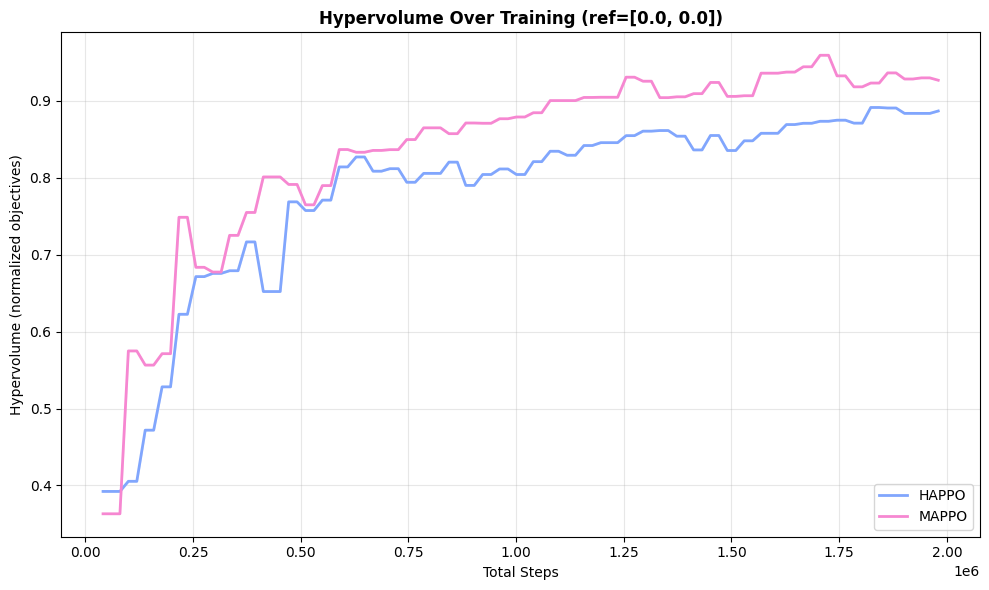

In [221]:
# for run_id in histories:
#     print(f"Run {run_id} - Algorithm: {histories[run_id]['algorithm'].iloc[0]}, "
#           f"Steps: {len(histories[run_id])}, "
#           f"Final 0: {histories[run_id]['0'].iloc[-1]:.2f}, "
#           f"Final 1: {histories[run_id]['1'].iloc[-1]:.2f}")
hv_over_time = compute_hypervolume_over_time(histories, HYPERVOLUME_REF_POINT)

if hv_over_time:
    fig_hv_time = plot_hypervolume_over_time(hv_over_time)
    if SAVE_FIGURES:
        fig_hv_time.savefig(OUTPUT_DIR / "hypervolume_over_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
else:
    print("No data for HV over time")


## 7. Expected Utility Over Time

In [215]:
from morl_baselines.common.performance_indicators import expected_utility
from morl_baselines.common.pareto import filter_pareto_dominated

def compute_expected_utility_over_time(histories: Dict[str, pd.DataFrame],
                                       runs_df: pd.DataFrame,
                                       num_bins: int = 100) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """Compute expected utility (morl_baselines) over time for each algorithm.

    At each step t, the current front = each run's most recent (norm_obj0, norm_obj1).
    EU = mean over weights of max scalarized point on that front.

    Returns: algo -> (steps, eu_values, zeros).
    """
    weights_lookup = {
        row["run_id"]: np.array([row["weight_0"], row["weight_1"]])
        for _, row in runs_df.iterrows()
    }

    # Global normalization bounds
    all_obj0, all_obj1 = [], []
    for hist in histories.values():
        valid = hist.dropna(subset=["total_num_steps", "0", "1"])
        all_obj0.extend(valid["0"].tolist())
        all_obj1.extend(valid["1"].tolist())

    if not all_obj0:
        return {}

    min0, max0 = min(all_obj0), max(all_obj0)
    min1, max1 = min(all_obj1), max(all_obj1)
    range0 = max0 - min0 if max0 != min0 else 1.0
    range1 = max1 - min1 if max1 != min1 else 1.0

    # Group by algorithm
    algo_histories: Dict[str, List[pd.DataFrame]] = {}
    for run_id, hist in histories.items():
        if len(hist) == 0:
            continue
        algo = hist["algorithm"].iloc[0] if "algorithm" in hist.columns else "UNKNOWN"
        algo_histories.setdefault(algo, []).append(hist)

    results: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]] = {}
    for algo, hist_list in algo_histories.items():
        # Build (steps, norm_point) timeline per run
        run_data = []
        run_weights = []
        for hist in hist_list:
            run_id = hist["run_id"].iloc[0]
            valid_rows = hist.dropna(subset=["total_num_steps", "0", "1"])
            pts = sorted(
                [(row["total_num_steps"],
                  np.array([(row["0"] - min0) / range0, (row["1"] - min1) / range1]))
                 for _, row in valid_rows.iterrows()],
                key=lambda x: x[0]
            )
            if pts:
                run_data.append(pts)
                run_weights.append(weights_lookup.get(run_id, np.array([0.5, 0.5])))

        if not run_data:
            continue

        weights_set = run_weights
        all_steps = [s for pts in run_data for s, _ in pts]
        step_grid = np.linspace(min(all_steps), max(all_steps), num_bins)

        eu_values = []
        for t in step_grid:
            front = []
            for pts in run_data:
                past = [p for s, p in pts if s <= t]
                if past:
                    front.append(past[-1])
            front = filter_pareto_dominated(np.array(front))
            eu_val = expected_utility(front, weights_set) if front.size > 0 else np.nan
            eu_values.append(eu_val)

        eu_arr = np.array(eu_values)
        results[algo] = (step_grid, eu_arr, np.zeros_like(eu_arr))

    return results


def plot_expected_utility_over_time(eu_over_time: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]) -> plt.Figure:
    """Plot expected utility learning curves with std shading."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo, data in eu_over_time.items():
        steps, eu_mean, eu_std = data
        color = COLORS.get(algo, "#333")
        label = algo if ALGORITHM_COMPARISON else f"{OBJECTIVE_NAMES}"
        
        ax.plot(steps, eu_mean, color=color, linewidth=2, label=label)
        ax.fill_between(steps, eu_mean - eu_std, eu_mean + eu_std,
                        color=color, alpha=0.15)
        
        # Annotate final value
        ax.annotate(f"{eu_mean[-1]:.2f}",
                   xy=(steps[-1], eu_mean[-1]), xytext=(5, 0),
                   textcoords='offset points', fontsize=9, color=color)
    
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Expected Utility (normalized)")
    ax.set_title("Expected Utility Over Training", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


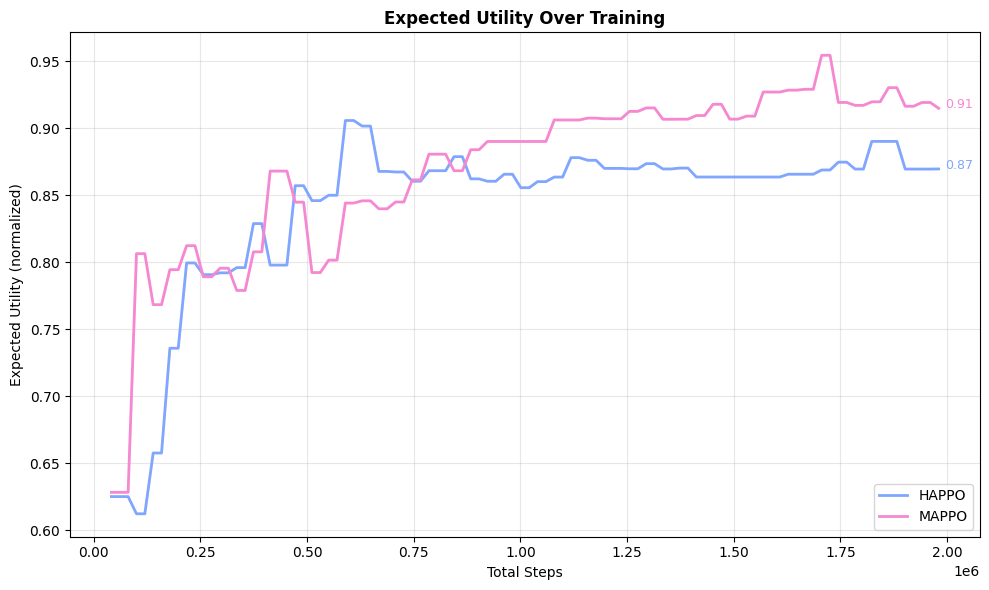

In [216]:
eu_over_time = compute_expected_utility_over_time(histories, df)
    
if eu_over_time:
    fig_eu_time = plot_expected_utility_over_time(eu_over_time)
    if SAVE_FIGURES:
        fig_eu_time.savefig(OUTPUT_DIR / "expected_utility_over_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
else:
    print("No data for expected utility over time")

## 8. Training Time per Weight

In [217]:
def fetch_training_times(runs_df, entity: str, project: str) -> pd.DataFrame:
    """Fetch training duration per run from wandb system metrics.
    Returns DataFrame with columns: run_id, algorithm, weight_idx, weight_0, weight_1, duration_min."""
    api = wandb.Api()
    rows = []
    for _, row in runs_df.iterrows():
        run_id = row["run_id"]
        run_new_id = run_id.split("-")[-1] if "-" in run_id else run_id
        try:
            run_obj = api.run(f"{entity}/{project}/{run_new_id}")
            runtime_sec = run_obj.summary.get("_runtime", 0)
            rows.append({
                "run_id": run_id,
                "algorithm": row["algorithm"],
                "weight_0": row["weight_0"],
                "weight_1": row["weight_1"],
                "weight_idx": int(row["weight_0"]*100),
                "duration_min": runtime_sec / 60.0,
            })
        except Exception as e:
            print(f"Failed to fetch runtime for {run_new_id}: {e}")
    return pd.DataFrame(rows)


def plot_training_time(time_df: pd.DataFrame) -> plt.Figure:
    """Scatter + box plot of training time per weight index, grouped by algorithm.
    Designed for many weights (e.g. 100)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [3, 1]})
    
    algos = sorted(time_df["algorithm"].unique())
    
    # Left: scatter plot of duration vs weight_idx
    ax = axes[0]
    for algo in algos:
        algo_df = time_df[time_df["algorithm"] == algo].sort_values("weight_idx")
        color = COLORS.get(algo, "#333")
        marker = MARKERS.get(algo, "o")
        ax.scatter(algo_df["weight_idx"], algo_df["duration_min"],
                  c=color, marker=marker, s=30, alpha=0.7, label=algo, edgecolors="gray", linewidths=0.5)
        
        # Mean line
        mean_dur = algo_df["duration_min"].mean()
        ax.axhline(mean_dur, color=color, linestyle="--", alpha=0.5, linewidth=1)
    
    ax.set_xlabel("Weight Index")
    ax.set_ylabel("Training Time (minutes)")
    ax.set_title("Training Time per Weight", fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Right: box plot per algorithm
    ax2 = axes[1]
    box_data = [time_df[time_df["algorithm"] == algo]["duration_min"].values for algo in algos]
    bp = ax2.boxplot(box_data, labels=algos, patch_artist=True, widths=0.5)
    for patch, algo in zip(bp["boxes"], algos):
        patch.set_facecolor(COLORS.get(algo, "#333"))
        patch.set_alpha(0.6)
    ax2.set_ylabel("Training Time (minutes)")
    ax2.set_title("Distribution", fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

In [218]:

time_df = fetch_training_times(df, WANDB_ENTITY, WANDB_PROJECT)
print(f"Fetched training times for {len(time_df)} runs")
print(f"Total training time: {time_df['duration_min'].sum():.1f} min ({time_df['duration_min'].sum() / 60:.1f} hrs)")


Fetched training times for 101 runs
Total training time: 4514.1 min (75.2 hrs)



--- Training Time per Algorithm (minutes) ---
  HAPPO: mean=44.78 ± std=3.42  [min=39.27, max=51.16]  (n=53)
  MAPPO: mean=44.60 ± std=3.14  [min=38.88, max=51.04]  (n=48)


/tmp/ipykernel_2555/911651633.py:54: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



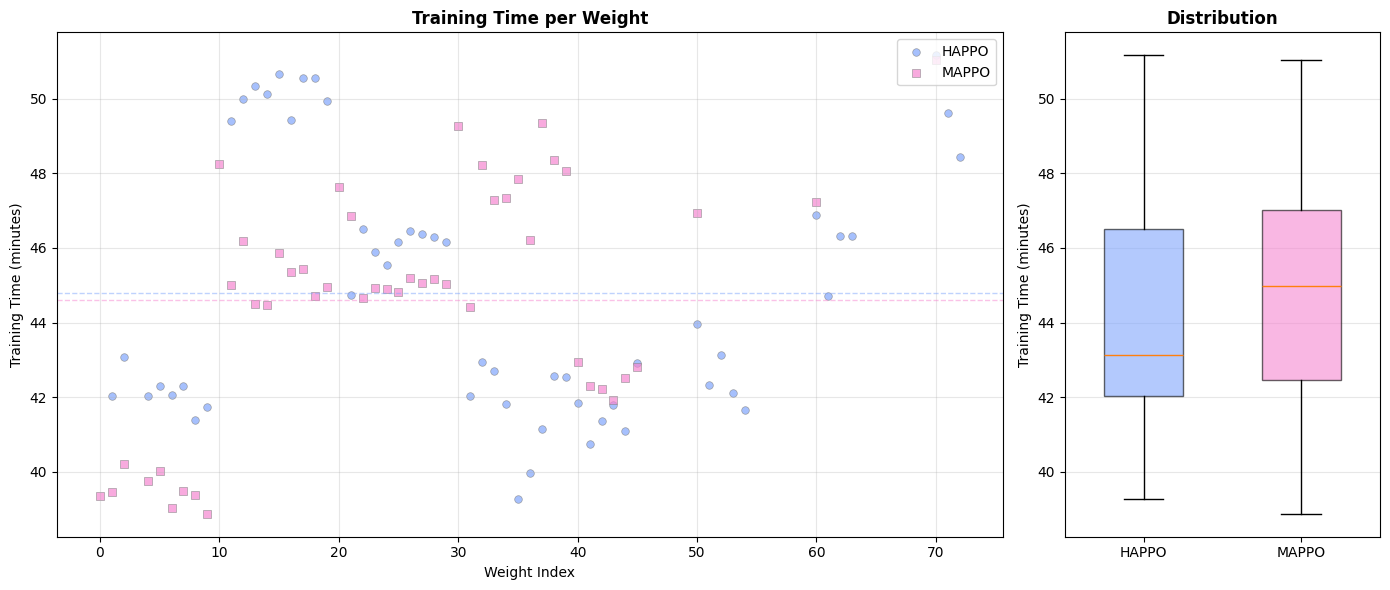

In [219]:
# if WANDB_AVAILABLE and USE_WANDB_API:
print("\n--- Training Time per Algorithm (minutes) ---")
for algo in sorted(time_df["algorithm"].unique()):
    algo_times = time_df[time_df["algorithm"] == algo]["duration_min"]
    print(f"  {algo}: mean={algo_times.mean():.2f} ± std={algo_times.std():.2f}  "
            f"[min={algo_times.min():.2f}, max={algo_times.max():.2f}]  "
            f"(n={len(algo_times)})")

if not time_df.empty:
    fig_time = plot_training_time(time_df)
    if SAVE_FIGURES:
        fig_time.savefig(OUTPUT_DIR / "training_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
else:
    print("No training time data available")